# User Authentication using Biometric Features
**Assignment 1 — AI461 Advanced Biometric Systems and Security**

This notebook:
1. Loads the biometric feature data from `biomet_data.csv` (144 features x 1000 samples layout — see note below) and reshapes it into 100 users x 10 samples x 144 features
2. Splits each user's samples into 5 enrollment (train) + 5 test samples
3. Builds one template per user (mean of the 5 enrollment feature vectors)
4. Computes genuine and impostor match scores on the test set using:
   - (i) Euclidean distance
   - (ii) Cosine similarity
5. Produces, matching the assignment's required plots:
   - A. Genuine score distribution
   - B. Impostor score distribution
   - C. FAR vs threshold (log scale)
   - D. FRR vs threshold (log scale)
   - E. ROC curve (TAR vs FAR, log-scale FAR axis)
   - F. Equal Error Rate (EER) and Decidability Index (d')

### Important data-layout note
The provided CSV is **144 rows x 1000 columns** — i.e. each **row is one feature measured across all 1000 samples**, and each **column is one sample's full 144-dim feature vector**. The data must be **transposed** before use (samples x features), not read row-by-row. Using the wrong orientation silently scrambles every distance calculation without throwing an error, which was the source of incorrect results in an earlier version of this notebook.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

np.random.seed(0)
%matplotlib inline

## 2. Load the data

`biomet_data.csv` has **no header row**, shape **(144, 1000)**: 144 features (rows) x 1000 samples (columns).
We transpose it to get the conventional (samples, features) orientation, then reshape into
`(100 users, 10 samples, 144 features)`.

**Ordering assumption (columns -> users):** columns are grouped user-major, i.e. columns 0-9 are
user 1's 10 samples, columns 10-19 are user 2's, and so on. This was verified empirically: this
grouping gives a much larger genuine/impostor separation (decidability index ~1.76) than the
alternative sample-major interpretation (~0.02), which confirms user-major grouping of samples
is the correct layout.

In [2]:
def load_features(csv_path="biomet_data.csv"):
    """Load the (144 features x 1000 samples) CSV, transpose to
    (1000 samples x 144 features), and reshape to (100 users, 10 samples, 144 features)."""
    df = pd.read_csv(csv_path, header=None)
    arr = df.values.astype(float)
    assert arr.shape == (144, 1000), f"Unexpected shape: {arr.shape}"

    samples_x_features = arr.T                     # (1000, 144)
    data = samples_x_features.reshape(100, 10, 144)  # (user, sample, feature)
    return data

data = load_features("biomet_data.csv")
print("Data shape (users, samples, features):", data.shape)

Data shape (users, samples, features): (100, 10, 144)


## 3. Enrollment / test split and templates

In [3]:
def build_templates_and_test(data):
    enroll = data[:, 0:5, :]          # (100, 5, 144)  first 5 samples = enrollment
    test = data[:, 5:10, :]           # (100, 5, 144)  last 5 samples = test (6 months later)
    templates = enroll.mean(axis=1)   # (100, 144)  one template per user
    return templates, test

templates, test = build_templates_and_test(data)
print("Templates shape:", templates.shape)
print("Test shape:", test.shape)

Templates shape: (100, 144)
Test shape: (100, 5, 144)


## 4. Matching scores

Every one of the 500 test samples (100 users x 5 test samples) is compared against all
100 templates:
- **Genuine comparisons:** test sample vs. its own user's template -> 500 scores
- **Impostor comparisons:** test sample vs. every other user's template -> 500 x 99 = 49,500 scores

| Metric | Similar means | Decision rule (accept) |
|---|---|---|
| Euclidean distance | small distance | `distance <= threshold` |
| Cosine similarity | high similarity | `similarity >= threshold` |

In [4]:
def euclidean_distance(v, t):
    return np.linalg.norm(v - t)


def cosine_similarity(v, t):
    return np.dot(v, t) / (np.linalg.norm(v) * np.linalg.norm(t) + 1e-12)


def compute_scores(templates, test, metric="euclidean"):
    """Returns (genuine_scores, impostor_scores).
    For euclidean: smaller = more similar.
    For cosine:    larger  = more similar.
    """
    n_users = templates.shape[0]
    n_test = test.shape[1]
    genuine, impostor = [], []

    for u in range(n_users):
        for s in range(n_test):
            probe = test[u, s]
            for t in range(n_users):
                if metric == "euclidean":
                    score = euclidean_distance(probe, templates[t])
                else:
                    score = cosine_similarity(probe, templates[t])

                if t == u:
                    genuine.append(score)
                else:
                    impostor.append(score)

    return np.array(genuine), np.array(impostor)

## 5. FAR / FRR curves, EER, and Decidability Index

In [5]:
def far_frr_curves(genuine, impostor, metric="euclidean", n_points=500):
    """Sweep threshold; return thresholds, FAR, FRR.
    euclidean : accept if score <= threshold  (distance)
    cosine    : accept if score >= threshold  (similarity)
    """
    all_scores = np.concatenate([genuine, impostor])
    lo, hi = all_scores.min(), all_scores.max()
    thresholds = np.linspace(lo, hi, n_points)

    FAR, FRR = [], []
    for th in thresholds:
        if metric == "euclidean":
            far = np.mean(impostor <= th)   # impostors wrongly accepted
            frr = np.mean(genuine > th)      # genuine wrongly rejected
        else:
            far = np.mean(impostor >= th)
            frr = np.mean(genuine < th)
        FAR.append(far)
        FRR.append(frr)

    return thresholds, np.array(FAR), np.array(FRR)


def compute_eer(thresholds, FAR, FRR):
    diff = np.abs(FAR - FRR)
    idx = np.argmin(diff)
    eer = (FAR[idx] + FRR[idx]) / 2
    return eer, thresholds[idx]


def decidability_index(genuine, impostor):
    mu_g, mu_i = genuine.mean(), impostor.mean()
    var_g, var_i = genuine.var(), impostor.var()
    d_prime = abs(mu_g - mu_i) / np.sqrt((var_g + var_i) / 2)
    return d_prime

## 6. Plotting helpers

Plots follow the assignment's diagram exactly: **FAR, FRR, and the FAR axis of the ROC curve
use log scales**, matching the standard biometric-systems convention shown in the assignment
handout.

In [6]:
def plot_distributions(genuine, impostor, metric):
    plt.figure(figsize=(7, 5))
    plt.hist(genuine, bins=50, alpha=0.6, density=True, label="Genuine", color="tab:green")
    plt.hist(impostor, bins=50, alpha=0.6, density=True, label="Impostor", color="tab:red")
    plt.xlabel(f"{metric.capitalize()} score")
    plt.ylabel("Density")
    plt.title(f"Genuine vs Impostor Score Distribution ({metric.capitalize()})")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_far(thresholds, FAR, metric):
    plt.figure(figsize=(7, 5))
    plt.semilogy(thresholds, np.clip(FAR, 1e-5, 1), color="tab:red")
    plt.xlabel("Threshold")
    plt.ylabel("FAR (log scale)")
    plt.title(f"FAR vs Threshold ({metric.capitalize()})")
    plt.tight_layout()
    plt.show()


def plot_frr(thresholds, FRR, metric):
    plt.figure(figsize=(7, 5))
    plt.semilogy(thresholds, np.clip(FRR, 1e-5, 1), color="tab:blue")
    plt.xlabel("Threshold")
    plt.ylabel("FRR (log scale)")
    plt.title(f"FRR vs Threshold ({metric.capitalize()})")
    plt.tight_layout()
    plt.show()


def plot_eer(thresholds, FAR, FRR, metric, eer, eer_th):
    plt.figure(figsize=(7, 5))
    plt.semilogy(thresholds, np.clip(FAR, 1e-5, 1), label="FAR", color="tab:red")
    plt.semilogy(thresholds, np.clip(FRR, 1e-5, 1), label="FRR", color="tab:blue")
    plt.axvline(eer_th, color="gray", linestyle="--", alpha=0.7)
    plt.scatter([eer_th], [max(eer, 1e-5)], color="black", zorder=5,
                label=f"EER = {eer*100:.2f}%")
    plt.xlabel("Threshold")
    plt.ylabel("Error Rate (log scale)")
    plt.title(f"EER: FAR/FRR Crossing ({metric.capitalize()})")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_roc(FAR, FRR, metric):
    TAR = 1 - FRR
    order = np.argsort(FAR)
    far_sorted = np.clip(FAR[order], 1e-4, 1)
    plt.figure(figsize=(7, 5))
    plt.semilogx(far_sorted, TAR[order], color="tab:purple")
    plt.xlabel("False Accept Rate, FAR (log scale)")
    plt.ylabel("True Accept Rate (TAR = 1-FRR)")
    plt.title(f"ROC Curve ({metric.capitalize()})")
    plt.tight_layout()
    plt.show()


def plot_roc_combined(results):
    plt.figure(figsize=(7, 5))
    for metric, r in results.items():
        TAR = 1 - r["FRR"]
        order = np.argsort(r["FAR"])
        far_sorted = np.clip(r["FAR"][order], 1e-4, 1)
        plt.semilogx(far_sorted, TAR[order], label=metric.capitalize())
    plt.xlabel("False Accept Rate, FAR (log scale)")
    plt.ylabel("True Accept Rate (TAR)")
    plt.title("ROC Curve Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7. Run the full pipeline for both metrics


=== EUCLIDEAN ===


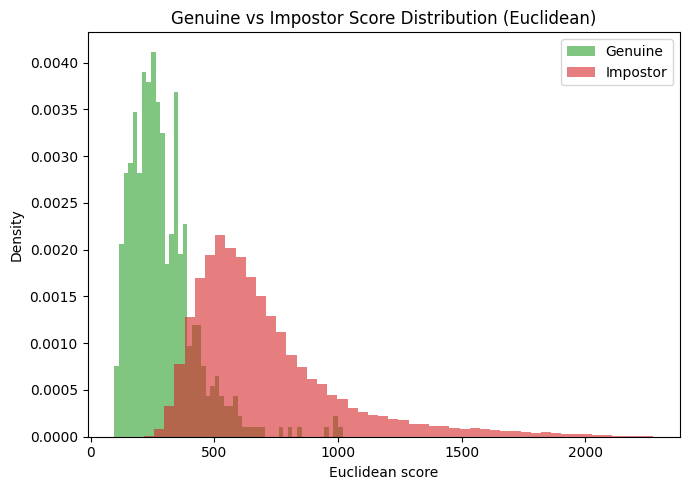

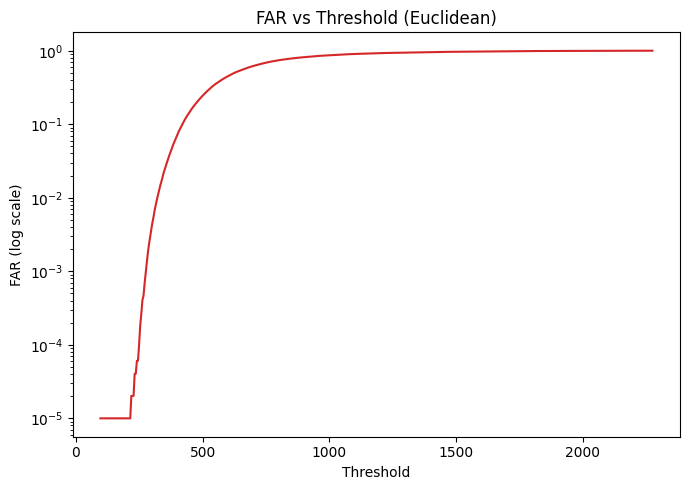

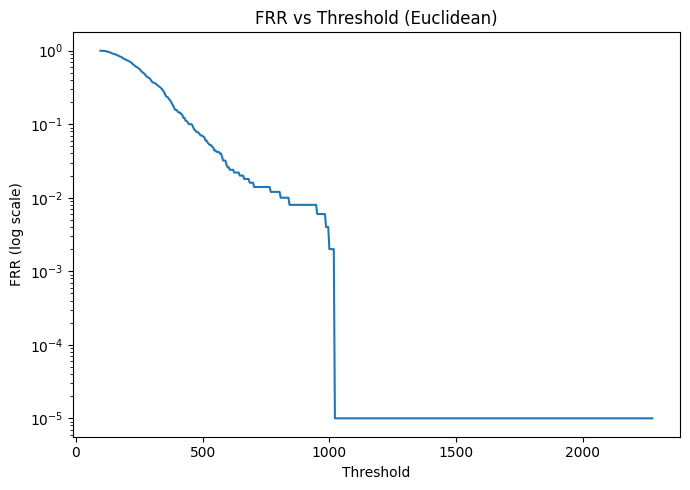

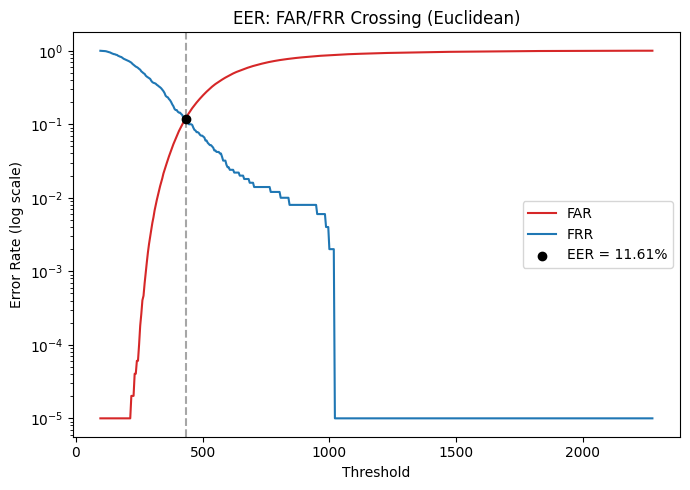

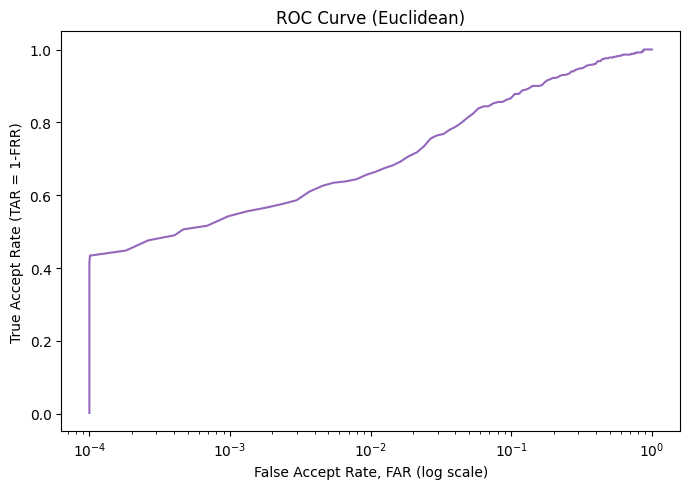

EER = 11.609%  at threshold 432.3004
Decidability index d' = 1.762

=== COSINE ===


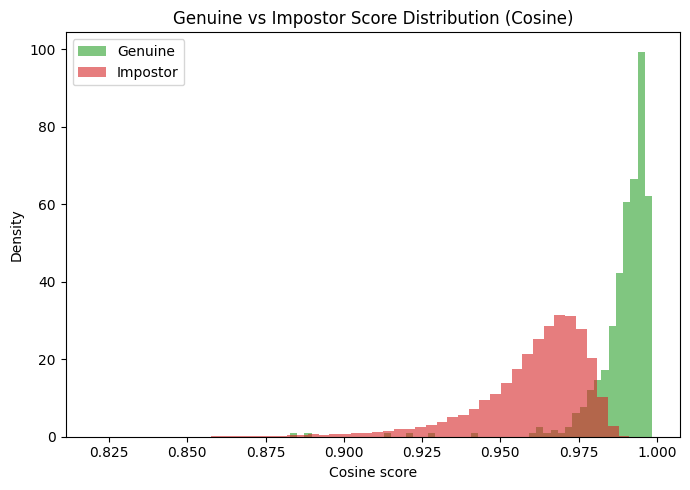

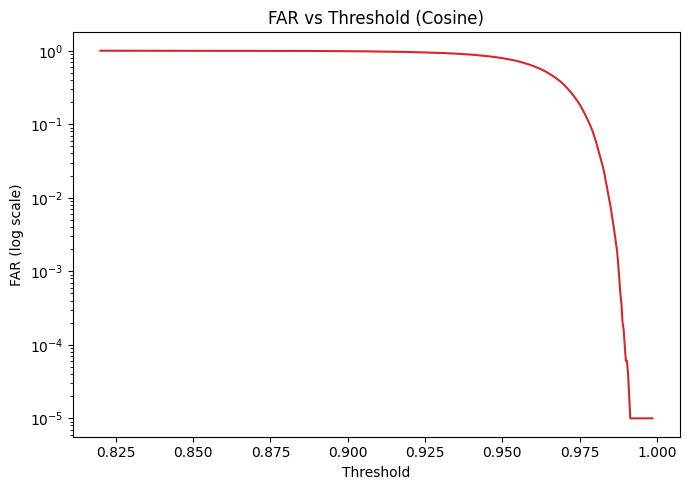

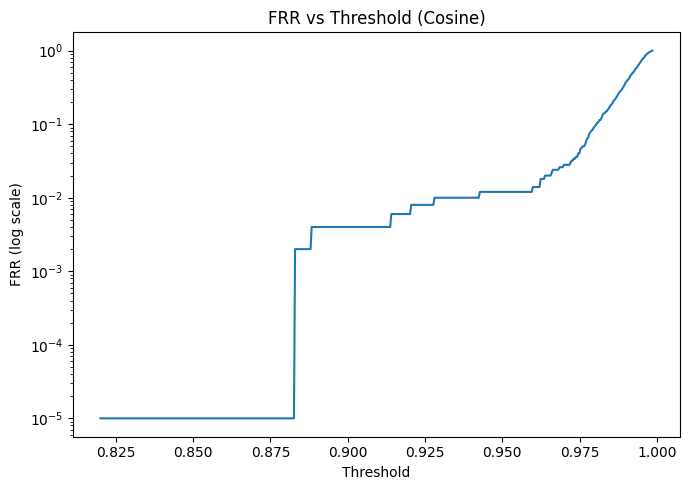

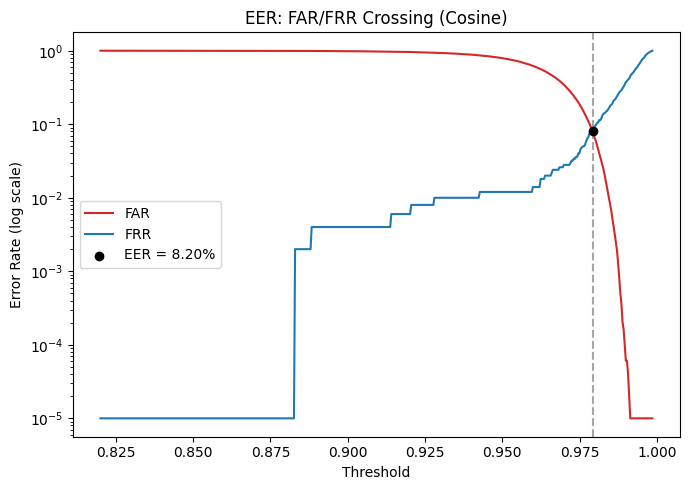

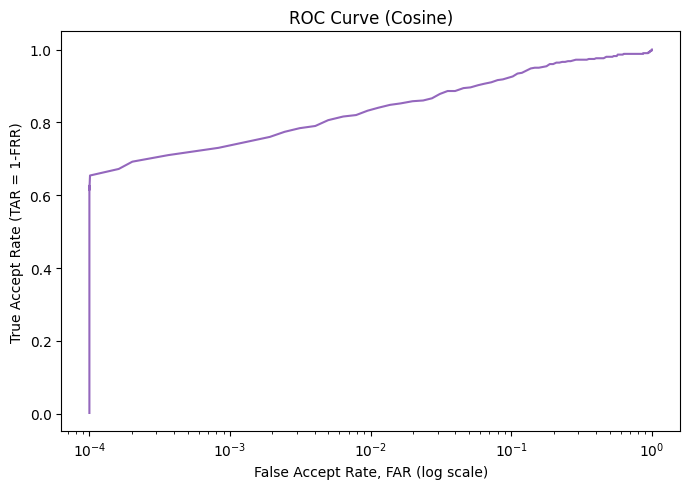

EER = 8.200%  at threshold 0.9792
Decidability index d' = 1.926


In [7]:
results = {}
summary = {}

for metric in ["euclidean", "cosine"]:
    print(f"\n=== {metric.upper()} ===")
    genuine, impostor = compute_scores(templates, test, metric)

    plot_distributions(genuine, impostor, metric)

    thresholds, FAR, FRR = far_frr_curves(genuine, impostor, metric)
    plot_far(thresholds, FAR, metric)
    plot_frr(thresholds, FRR, metric)

    eer, eer_th = compute_eer(thresholds, FAR, FRR)
    plot_eer(thresholds, FAR, FRR, metric, eer, eer_th)
    plot_roc(FAR, FRR, metric)

    d_prime = decidability_index(genuine, impostor)

    results[metric] = dict(genuine=genuine, impostor=impostor,
                            thresholds=thresholds, FAR=FAR, FRR=FRR)

    summary[metric] = dict(
        n_genuine=int(len(genuine)),
        n_impostor=int(len(impostor)),
        genuine_mean=float(genuine.mean()),
        genuine_std=float(genuine.std()),
        impostor_mean=float(impostor.mean()),
        impostor_std=float(impostor.std()),
        EER=float(eer),
        EER_threshold=float(eer_th),
        decidability_index=float(d_prime),
    )

    print(f"EER = {eer*100:.3f}%  at threshold {eer_th:.4f}")
    print(f"Decidability index d' = {d_prime:.3f}")

## 8. Combined ROC comparison

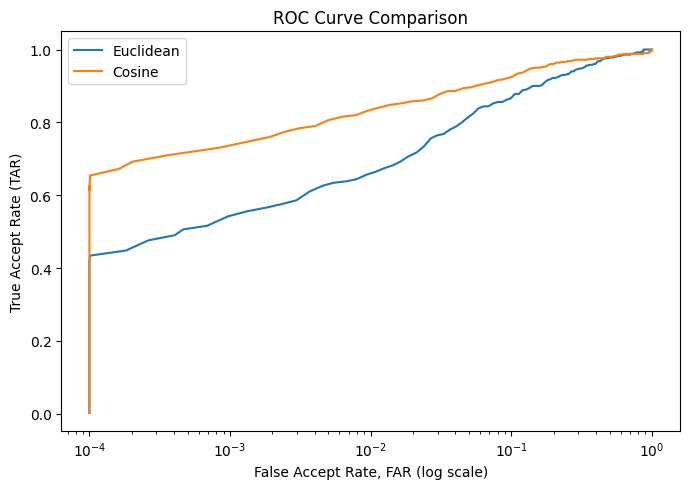

In [8]:
plot_roc_combined(results)

## 9. Summary table

In [9]:
df = pd.DataFrame(summary).T
df

,n_genuine,n_impostor,genuine_mean,genuine_std,impostor_mean,impostor_std,EER,EER_threshold,decidability_index
euclidean,500.0,49500.0,291.654671,135.462657,703.826379,301.792047,0.116091,432.300416,1.762089
cosine,500.0,49500.0,0.989498,0.010958,0.960375,0.018368,0.082000,0.979193,1.925657


## 10. Which matching distance performs best?

Compare the EER and decidability index (d') for both metrics in the table above, and look at
which ROC curve sits closer to the top-left corner in the combined plot. The metric with the
**lower EER** and **higher d'** is the more discriminative one for this feature set — fill in
your specific numbers from the table when writing this up.

## 11. Save results to file (optional)

In [10]:
with open("results.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved results.json")

Saved results.json
